In [75]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import MinMaxScaler

In [76]:
df = pd.read_csv(r'../data/cleaned/timestap_pjme.csv')

In [77]:
df

,Datetime,PJME_MW,year,month,day_name,hour
0,2002-12-31 01:00:00,26498.0,2002,12,Tuesday,1
1,2002-12-31 02:00:00,25147.0,2002,12,Tuesday,2
2,2002-12-31 03:00:00,24574.0,2002,12,Tuesday,3
3,2002-12-31 04:00:00,24393.0,2002,12,Tuesday,4
4,2002-12-31 05:00:00,24860.0,2002,12,Tuesday,5
...,...,...,...,...,...,...
145361,2018-01-01 20:00:00,44284.0,2018,1,Monday,20
145362,2018-01-01 21:00:00,43751.0,2018,1,Monday,21
145363,2018-01-01 22:00:00,42402.0,2018,1,Monday,22
145364,2018-01-01 23:00:00,40164.0,2018,1,Monday,23


In [78]:
df['Datetime'] = df['Datetime'].astype('datetime64[ms]')

In [79]:
df = df.sort_values('Datetime').reset_index(drop=True)

In [80]:
time_diffs = df['Datetime'].diff()
print(time_diffs.value_counts())

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [81]:
#gandlinng missing valuea and duplicates

In [82]:
# 1. Drop duplicate Datetime rows BEFORE reindexing
df = df.drop_duplicates(subset=['Datetime'], keep='first')

# 2. Set 'Datetime' as the index
df = df.set_index('Datetime')

# 3. Create complete hourly range
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')

# 4. Reindex to the unbroken hourly timeline (this will now work!)
df = df.reindex(full_idx)

# 5. Interpolate the 30 missing hourly values
df['PJME_MW'] = df['PJME_MW'].interpolate(method='linear')

# 6. Reset the index back
df = df.reset_index().rename(columns={'index': 'Datetime'})

In [83]:
df['year'] = df['Datetime'].dt.year
df['month'] = df['Datetime'].dt.month
df['day_name'] = df['Datetime'].dt.day_name()
df['hour'] = df['Datetime'].dt.hour

In [84]:
time_diffs = df['Datetime'].diff()
print(time_diffs.value_counts())

Datetime
0 days 01:00:00    145391
Name: count, dtype: int64


In [85]:
df[['hour','month','year']].isnull().sum()

hour     0
month    0
year     0
dtype: int64

In [86]:
df[['hour','month','year']] = df[['hour','month','year']].astype(int)
df

,Datetime,PJME_MW,year,month,day_name,hour
0,2002-01-01 01:00:00,30393.0,2002,1,Tuesday,1
1,2002-01-01 02:00:00,29265.0,2002,1,Tuesday,2
2,2002-01-01 03:00:00,28357.0,2002,1,Tuesday,3
3,2002-01-01 04:00:00,27899.0,2002,1,Tuesday,4
4,2002-01-01 05:00:00,28057.0,2002,1,Tuesday,5
...,...,...,...,...,...,...
145387,2018-08-02 20:00:00,44057.0,2018,8,Thursday,20
145388,2018-08-02 21:00:00,43256.0,2018,8,Thursday,21
145389,2018-08-02 22:00:00,41552.0,2018,8,Thursday,22
145390,2018-08-02 23:00:00,38500.0,2018,8,Thursday,23


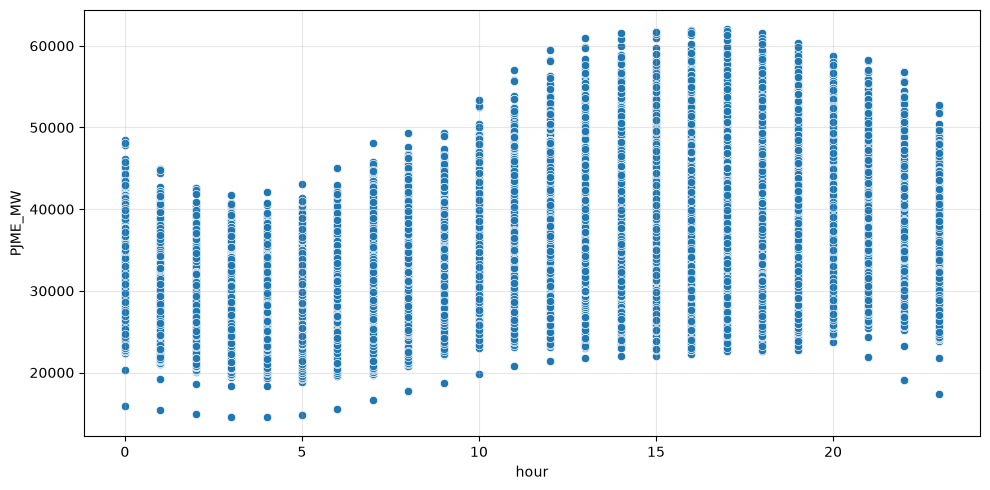

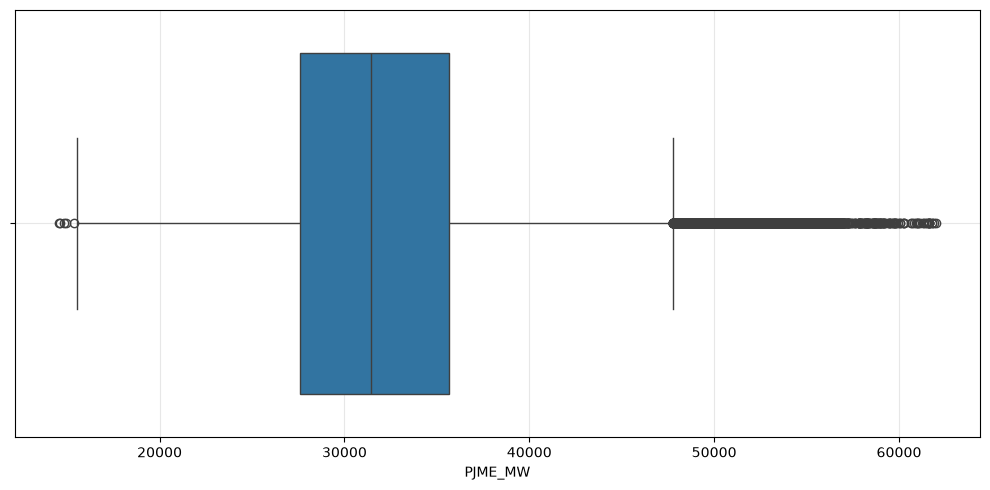

In [87]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, y="PJME_MW",x='hour')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="PJME_MW")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
df[df['PJME_MW']<=19000]

,Datetime,PJME_MW,year,month,day_name,hour
94918,2012-10-29 23:00:00,17422.0,2012,10,Monday,23
94919,2012-10-30 00:00:00,15919.0,2012,10,Tuesday,0
94920,2012-10-30 01:00:00,15390.0,2012,10,Tuesday,1
94921,2012-10-30 02:00:00,14955.0,2012,10,Tuesday,2
94922,2012-10-30 03:00:00,14586.0,2012,10,Tuesday,3
94923,2012-10-30 04:00:00,14544.0,2012,10,Tuesday,4
94924,2012-10-30 05:00:00,14821.0,2012,10,Tuesday,5
94925,2012-10-30 06:00:00,15526.0,2012,10,Tuesday,6
94926,2012-10-30 07:00:00,16688.0,2012,10,Tuesday,7
94927,2012-10-30 08:00:00,17734.0,2012,10,Tuesday,8


In [89]:
#feature engineering

In [90]:
df = df.drop(columns ='day_name')

In [91]:
df['day_num'] =  df['Datetime'].dt.dayofweek
df['day_of_month'] = df['Datetime'].dt.day
df['week_of_year'] = df['Datetime'].dt.isocalendar().week
df['is_weekend'] = (df['Datetime'].dt.dayofweek >= 5).astype(int)

In [92]:
df.head()

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend
0,2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,0
1,2002-01-01 02:00:00,29265.0,2002,1,2,1,1,1,0
2,2002-01-01 03:00:00,28357.0,2002,1,3,1,1,1,0
3,2002-01-01 04:00:00,27899.0,2002,1,4,1,1,1,0
4,2002-01-01 05:00:00,28057.0,2002,1,5,1,1,1,0


In [93]:
df['lag_1'] = df['PJME_MW'].shift(1)
df['lag_24'] = df['PJME_MW'].shift(24)
df['lag_168'] = df['PJME_MW'].shift(168)

In [94]:
df

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168
0,2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,0,NaN,NaN,NaN
1,2002-01-01 02:00:00,29265.0,2002,1,2,1,1,1,0,30393.0,NaN,NaN
2,2002-01-01 03:00:00,28357.0,2002,1,3,1,1,1,0,29265.0,NaN,NaN
3,2002-01-01 04:00:00,27899.0,2002,1,4,1,1,1,0,28357.0,NaN,NaN
4,2002-01-01 05:00:00,28057.0,2002,1,5,1,1,1,0,27899.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
145387,2018-08-02 20:00:00,44057.0,2018,8,20,3,2,31,0,45641.0,46912.0,46337.0
145388,2018-08-02 21:00:00,43256.0,2018,8,21,3,2,31,0,44057.0,45985.0,44542.0
145389,2018-08-02 22:00:00,41552.0,2018,8,22,3,2,31,0,43256.0,44094.0,42638.0
145390,2018-08-02 23:00:00,38500.0,2018,8,23,3,2,31,0,41552.0,40666.0,39276.0


In [95]:
df = df.dropna().reset_index(drop=True)

In [96]:
#rolling

In [97]:
df['rolling_mean_24'] = df['PJME_MW'].shift(1).rolling(window=24).mean()
df['rolling_std_24'] = df['PJME_MW'].shift(1).rolling(window=24).std()

df = df.dropna().reset_index(drop=True)

In [98]:
df

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2002-01-09 01:00:00,29082.0,2002,1,1,2,9,2,0,30943.0,29445.0,28121.0,34352.750000,3579.227464
1,2002-01-09 02:00:00,28154.0,2002,1,2,2,9,2,0,29082.0,28670.0,27437.0,34337.625000,3601.565467
2,2002-01-09 03:00:00,27829.0,2002,1,3,2,9,2,0,28154.0,28375.0,27301.0,34316.125000,3638.223698
3,2002-01-09 04:00:00,27759.0,2002,1,4,2,9,2,0,27829.0,28542.0,27533.0,34293.375000,3678.473523
4,2002-01-09 05:00:00,28308.0,2002,1,5,2,9,2,0,27759.0,29261.0,28405.0,34260.750000,3734.743158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145195,2018-08-02 20:00:00,44057.0,2018,8,20,3,2,31,0,45641.0,46912.0,46337.0,40021.875000,6475.317097
145196,2018-08-02 21:00:00,43256.0,2018,8,21,3,2,31,0,44057.0,45985.0,44542.0,39902.916667,6368.579836
145197,2018-08-02 22:00:00,41552.0,2018,8,22,3,2,31,0,43256.0,44094.0,42638.0,39789.208333,6278.997878
145198,2018-08-02 23:00:00,38500.0,2018,8,23,3,2,31,0,41552.0,40666.0,39276.0,39683.291667,6224.428358


In [99]:
# cleaneddata

In [100]:
df.to_csv(r'../data/cleaned/cleaned.csv')

In [101]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

In [102]:
cols=['lag_1','lag_24','lag_168','rolling_mean_24','rolling_std_24']

In [103]:
#scaling 
scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_df[cols] = scaler.fit_transform(train_df[cols])
val_df[cols] = scaler.transform(val_df[cols])
test_df[cols] = scaler.transform(test_df[cols])

train_df['PJME_MW'] = target_scaler.fit_transform(train_df[['PJME_MW']])
test_df['PJME_MW'] = target_scaler.transform(test_df[['PJME_MW']])
val_df['PJME_MW'] = target_scaler.transform(val_df[['PJME_MW']])

In [104]:
train_df

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2002-01-09 01:00:00,0.306289,2002,1,1,2,9,2,0,0.345497,0.313937,0.286042,0.456556,0.234076
1,2002-01-09 02:00:00,0.286738,2002,1,2,2,9,2,0,0.306289,0.297609,0.271632,0.456097,0.236377
2,2002-01-09 03:00:00,0.279890,2002,1,3,2,9,2,0,0.286738,0.291394,0.268766,0.455444,0.240153
3,2002-01-09 04:00:00,0.278416,2002,1,4,2,9,2,0,0.279890,0.294912,0.273654,0.454754,0.244299
4,2002-01-09 05:00:00,0.289982,2002,1,5,2,9,2,0,0.278416,0.310060,0.292026,0.453764,0.250095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101635,2013-08-13 20:00:00,0.560813,2013,8,20,1,13,33,0,0.592205,0.599199,0.419973,0.532663,0.430098
101636,2013-08-13 21:00:00,0.558074,2013,8,21,1,13,33,0,0.560813,0.590393,0.431118,0.530359,0.422228
101637,2013-08-13 22:00:00,0.517455,2013,8,22,1,13,33,0,0.558074,0.551796,0.412262,0.528420,0.415776
101638,2013-08-13 23:00:00,0.449342,2013,8,23,1,13,33,0,0.517455,0.477594,0.363194,0.526359,0.411341


In [105]:
val_df

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
101640,2013-08-14 01:00:00,0.319751,2013,8,1,2,14,33,0,0.379374,0.349141,0.263647,0.522917,0.415302
101641,2013-08-14 02:00:00,0.274055,2013,8,2,2,14,33,0,0.319751,0.311767,0.234952,0.521153,0.422386
101642,2013-08-14 03:00:00,0.243148,2013,8,3,2,14,33,0,0.274055,0.290909,0.217950,0.518890,0.434119
101643,2013-08-14 04:00:00,0.223891,2013,8,4,2,14,33,0,0.243148,0.280733,0.211904,0.516024,0.450687
101644,2013-08-14 05:00:00,0.218645,2013,8,5,2,14,33,0,0.223891,0.289729,0.220752,0.512612,0.471038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123415,2016-02-07 08:00:00,0.347898,2016,2,8,6,7,5,1,0.329864,0.381839,0.309891,0.344615,0.072727
123416,2016-02-07 09:00:00,0.359654,2016,2,9,6,7,5,1,0.347898,0.398820,0.325103,0.342579,0.068262
123417,2016-02-07 10:00:00,0.355019,2016,2,10,6,7,5,1,0.359654,0.388560,0.322996,0.340228,0.059683
123418,2016-02-07 11:00:00,0.344823,2016,2,11,6,7,5,1,0.355019,0.371411,0.306268,0.338215,0.053128


In [106]:
test_df

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
123420,2016-02-07 13:00:00,0.327568,2016,2,13,6,7,5,1,0.336248,0.337112,0.278205,0.335566,0.048513
123421,2016-02-07 14:00:00,0.320615,2016,2,14,6,7,5,1,0.327568,0.320510,0.265606,0.334993,0.048556
123422,2016-02-07 15:00:00,0.317244,2016,2,15,6,7,5,1,0.320615,0.309913,0.257095,0.335000,0.048548
123423,2016-02-07 16:00:00,0.323480,2016,2,16,6,7,5,1,0.317244,0.306900,0.262256,0.335440,0.047735
123424,2016-02-07 17:00:00,0.343811,2016,2,17,6,7,5,1,0.323480,0.322638,0.283451,0.336435,0.045987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145195,2018-08-02 20:00:00,0.621784,2018,8,20,3,2,31,0,0.655156,0.681934,0.669820,0.628587,0.532395
145196,2018-08-02 21:00:00,0.604909,2018,8,21,3,2,31,0,0.621784,0.662404,0.632003,0.624977,0.521400
145197,2018-08-02 22:00:00,0.569009,2018,8,22,3,2,31,0,0.604909,0.622564,0.591889,0.621527,0.512173
145198,2018-08-02 23:00:00,0.504709,2018,8,23,3,2,31,0,0.569009,0.550342,0.521058,0.618313,0.506551


In [107]:
train_df.to_csv(r"../data/cleaned/train.csv",index=False)
test_df.to_csv(r"../data/cleaned/test.csv",index=False)
val_df.to_csv(r"../data/cleaned/val.csv",index=False)

In [108]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)